## Libaries


In [ ]:
# libs needed. Use the install line below :)
# !pip install torch numpy matplotlib torchview torchvision scikit-learn
import os
import csv
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc


print("ok :)")

ok :)


# Load CIFAR-10 Dataset

In [ ]:
###########################################################################
# Transform the train and validation dataset
# CIFAR-10 mean and std used after ToTensor() scales images to [0, 1]
mean = [0.4914, 0.4822, 0.4465] # Cite: https://sidthoviti.com/fine-tuning-resnet50-pretrained-on-imagenet-for-cifar-10/
std = [0.2470, 0.2435, 0.2616]

# Training transform: data augmentation
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4), #Random cropping here
    transforms.RandomHorizontalFlip(), # Random flips
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Validation/test transform: no random augmentation
transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


###########################################################################
#Load train and validation dataset
full_train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
val_full_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_eval)

#Split the full traning dataset into train (80%) and validation (20%)
train_size = int(0.8 * len(full_train_dataset)) #Train
indices = torch.randperm(len(full_train_dataset)).tolist() #Train
train_indices = indices[:train_size] #Train
val_indices = indices[train_size:] #val
train_dataset = Subset(full_train_dataset, train_indices) #Train
val_dataset = Subset(val_full_dataset, val_indices) #Val



# Batch size
batch_size = 128
print("Batch size: ", batch_size)

# Create loaders for train and validation dataset
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True)

val_loader = DataLoader( 
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False)


###########################################################################
# Test dataset
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_eval)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False)


###########################################################################
# Check it works
classes = test_loader.dataset.classes
print(classes)


print("ok :)")

/home/akselu24/Documents/AI_Tools_F26/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Batch size:  128
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


# Visualization of dataset

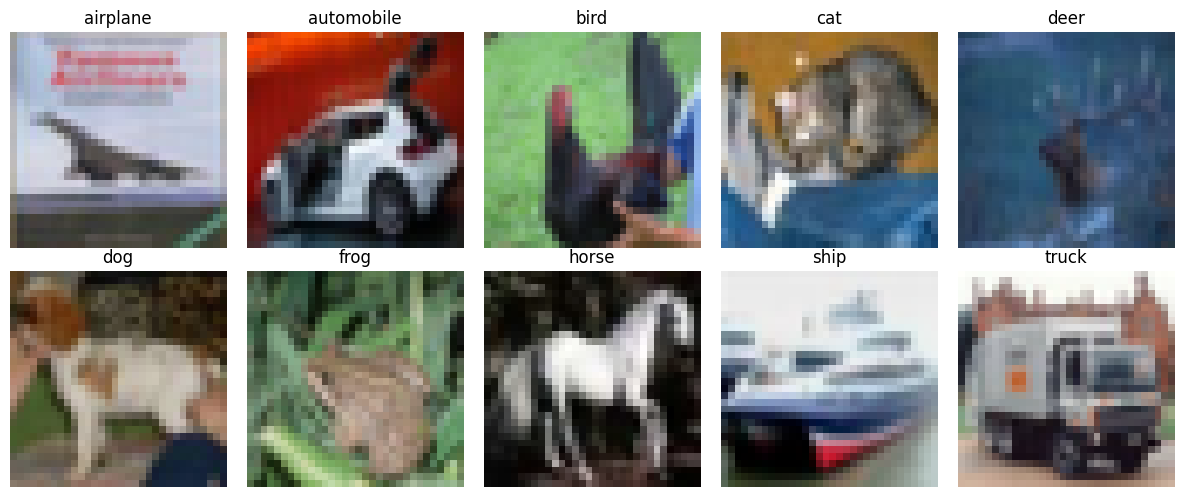

In [ ]:
# CIFAR-10 class names
classes = test_dataset.classes

# Mean and std used in Normalize
mean_tensor = torch.tensor(mean).view(3, 1, 1)
std_tensor = torch.tensor(std).view(3, 1, 1)

def unnormalize(image):
    image = image * std_tensor + mean_tensor
    image = torch.clamp(image, 0, 1)
    return image


# Find one image from each class
images_per_class = {}
labels_per_class = {}

for image, label in test_dataset:
    if label not in images_per_class:
        images_per_class[label] = image
        labels_per_class[label] = label

    if len(images_per_class) == 10: # Break att the end
        break


# Plot one image from each class
plt.figure(figsize=(12, 5))

for i in range(10):
    image = images_per_class[i]
    image = unnormalize(image)

    # Convert from PyTorch format: [C, H, W] to matplotlib format: [H, W, C]
    image = image.permute(1, 2, 0)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(classes[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Setting up MobileNetV1

In [ ]:
########################################################3
# Cite: https://sahiltinky94.medium.com/know-about-mobilenet-v1-implementation-from-scratch-using-pytorch-7dd594f4d99b 

class DepthWiseSeperable(nn.Module):

    def __init__(self, in_channels , out_channels , stride ):
        """
        DepthWiseSeperable block of MobileNet which performs the following operations:
        (a) depthwise convolution by applying a separate filter for each channel
        (b) pointwise convolutions are applied which combine the filtered result by implementing 1 × 1 convolution
        
            Note:
                1. groups = in_channels used for depthwise convolution
                2. in_channels and out_channels are same for depthwise convolution
                3. bias = False due to the usage of BatchNorm 
                4. To generate same height and width of output feature map as the input feature map, following should be padding for
                    * 1x1 conv : p=0
                    * 3x3 conv : p=1
                    * 5x5 conv : p=2


        Args:
          in_channels (int) : number of input channels
          out_channels (int) : number of output channels 
          stride (int) : stride used for depthwise convolution

        Attributes:
            Depthwise seperable convolutional block

        """

        super(DepthWiseSeperable,self).__init__()
        
        # groups used here
        self.depthwise = nn.Conv2d(in_channels = in_channels , out_channels = in_channels , stride = stride , padding = 1, kernel_size = 3 , groups=in_channels , bias = False)
        self.bn1 = nn.BatchNorm2d(in_channels)

        self.pointwise = nn.Conv2d(in_channels = in_channels , out_channels = out_channels , stride = 1 , padding = 0, kernel_size = 1, bias = False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU()

    def forward(self,x):

        x = self.depthwise(x)
        x = self.bn1(x)
        x = self.relu(x)
        
        x = self.pointwise(x)
        x = self.bn2(x)
        x = self.relu(x)
        
        return x



################################################################################################


class MobileNetV1(nn.Module):
    
    def __init__(self, num_classes=10):
        
        super(MobileNetV1, self).__init__()

        # Initial convolution layer
        self.features1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        
        # Depthwise separable convolutions
        self.features = nn.Sequential(
            self.features1,                      # Inserting the above features here
            DepthWiseSeperable(32, 64, 1),
            DepthWiseSeperable(64, 128, 2),
            DepthWiseSeperable(128, 128, 1),
            DepthWiseSeperable(128, 256, 2),
            DepthWiseSeperable(256, 256, 1),
            DepthWiseSeperable(256, 512, 2),
            
            DepthWiseSeperable(512, 512, 1),
            DepthWiseSeperable(512, 512, 1),
            DepthWiseSeperable(512, 512, 1),
            DepthWiseSeperable(512, 512, 1),
            DepthWiseSeperable(512, 512, 1),

            DepthWiseSeperable(512, 1024, 2),
            DepthWiseSeperable(1024, 1024, 1)

        )
        
        # Average pooling and classifier
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(1024, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Training the model

In [ ]:
# Folder path
folder_path = "./mobilenet_metrics_with_aug"
os.makedirs(folder_path, exist_ok=True)


# Create/overwrite CSV file and write header
csv_log_file = os.path.join(folder_path, "training_log.csv")
with open(csv_log_file, mode="w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "train_loss", "train_acc", "val_loss", "val_acc"])


# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


# Instantiate the model
model = MobileNetV1(num_classes=10)

# For Ucloud, use all available GPUs
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

# Use the available...
model = model.to(device)


# Define loss function and optimizer
lossFunction = nn.CrossEntropyLoss()
optimizer = optim.Adam(params=model.parameters(), lr=0.001)


# Number of steps for training
num_epochs = 100

# Early stopping settings
patience = 10
best_val_loss = float("inf")
epochs_without_improvement = 0
best_model_weights = copy.deepcopy(model.state_dict())


# For storing results
train_losses = []
train_accuracies = []
val_losses = [] 
val_accuracies = []

# Eval model similar to class
def evaluate(model, dataloader):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, Y_batch in dataloader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            outputs = model(X_batch)
            loss = lossFunction(outputs, Y_batch)

            total_loss += loss.item() * X_batch.size(0)

            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == Y_batch).sum().item()
            total += Y_batch.size(0)

    average_loss = total_loss / total
    accuracy = correct / total * 100

    return average_loss, accuracy


# Training loop
for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for X_batch, Y_batch in train_loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        # Forward pass
        outputs = model(X_batch)
        loss = lossFunction(outputs, Y_batch)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Save statistics
        running_loss += loss.item() * X_batch.size(0)

        predictions = torch.argmax(outputs, dim=1)
        correct += (predictions == Y_batch).sum().item()
        total += Y_batch.size(0)

    train_loss = running_loss / total
    train_acc = correct / total * 100

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)


    #Evaluate at epoch level
    val_loss, val_acc = evaluate(model, val_loader)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    

    # print the output for visual understanding of progresss
    print(
        f"Epoch [{epoch+1}/{num_epochs}]:  "
        f"Train Loss: {train_loss:.4f}, "
        f"Train Acc: {train_acc:.2f}%  |  "
        f"Val Loss: {val_loss:.4f}, " 
        f"Val Acc: {val_acc:.2f}%"
    )
    # Write to log file if needs to be used
    with open(csv_log_file, mode="a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            epoch + 1,
            train_loss,
            train_acc,
            val_loss,
            val_acc
        ])


    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        best_model_weights = copy.deepcopy(model.state_dict())
        # print("Validation loss improved. Saving model.")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= patience:
        print("Early stopping triggered.")
        break






# Restore best model weights
model.load_state_dict(best_model_weights)

# Finished with training
print('Training finished.')

cpu
Epoch [1/100]:  Train Loss: 1.8587, Train Acc: 29.88%  |  Val Loss: 1.6274, Val Acc: 41.07%
Epoch [2/100]:  Train Loss: 1.4979, Train Acc: 44.93%  |  Val Loss: 1.4043, Val Acc: 50.23%
Epoch [3/100]:  Train Loss: 1.3272, Train Acc: 52.15%  |  Val Loss: 1.2675, Val Acc: 55.60%
Epoch [4/100]:  Train Loss: 1.1901, Train Acc: 56.99%  |  Val Loss: 1.1349, Val Acc: 59.06%
Epoch [5/100]:  Train Loss: 1.0711, Train Acc: 61.27%  |  Val Loss: 1.0272, Val Acc: 63.80%
Epoch [6/100]:  Train Loss: 0.9691, Train Acc: 65.46%  |  Val Loss: 0.9333, Val Acc: 66.71%
Epoch [7/100]:  Train Loss: 0.8760, Train Acc: 69.08%  |  Val Loss: 0.8650, Val Acc: 70.16%
Epoch [8/100]:  Train Loss: 0.8008, Train Acc: 71.76%  |  Val Loss: 0.8084, Val Acc: 72.18%
Epoch [9/100]:  Train Loss: 0.7419, Train Acc: 74.19%  |  Val Loss: 0.7767, Val Acc: 73.36%
Epoch [10/100]:  Train Loss: 0.6910, Train Acc: 75.79%  |  Val Loss: 0.6979, Val Acc: 75.81%
Epoch [11/100]:  Train Loss: 0.6370, Train Acc: 77.78%  |  Val Loss: 0.6635

# Plot progress during training

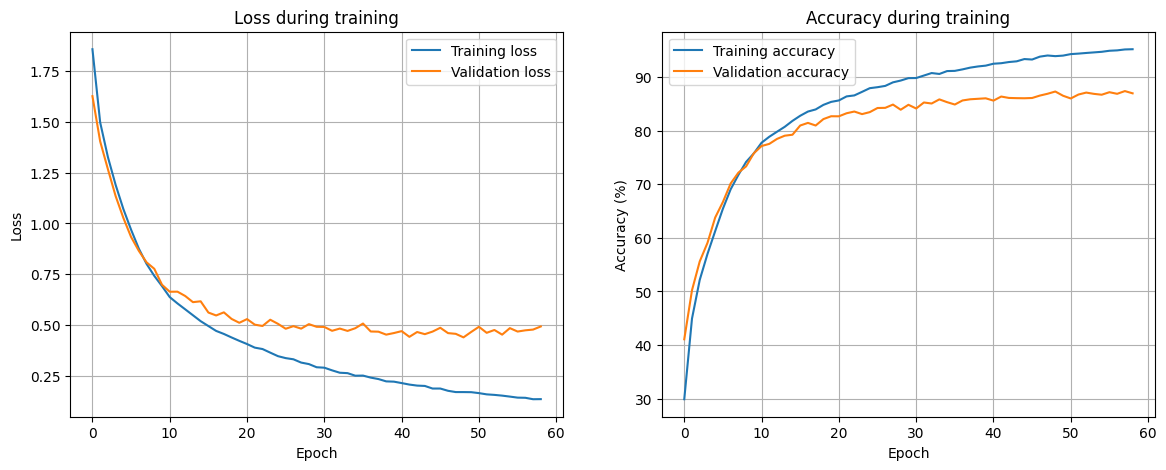

In [6]:
# figure size
plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss during training")
plt.legend()
plt.grid()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Training accuracy")
plt.plot(val_accuracies, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy during training")
plt.legend()
plt.grid()

plt.savefig(folder_path + "/loss_and_accuracy_during_training.pdf")
plt.show()

# Evaluate the model

In [7]:
# Evaluate accuracy on test dataset
model.eval()

def get_predictions_from_loader(model, dataloader):
    all_preds = []
    all_true = []

    with torch.no_grad():
        for X_batch, Y_batch in dataloader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1)

            all_preds.append(preds.cpu())
            all_true.append(Y_batch.cpu())

    y_pred = torch.cat(all_preds)
    y_true = torch.cat(all_true)

    return y_true, y_pred

# Get predictions
y_true_test, y_pred_test = get_predictions_from_loader(model, test_loader)
test_acc = (y_pred_test == y_true_test).float().mean().item() * 100
print(f"Accuracy on test data: {test_acc:.2f}%")

# Save test accuracy to txt file
with open(os.path.join(folder_path, "test_accuracy.txt"), "w") as f:
    f.write("Test results\n")
    f.write("====================\n")
    f.write(f"Accuracy on test data: {test_acc:.2f}%\n")
    f.write(f"Correct predictions: {(y_pred_test == y_true_test).sum().item()}\n")
    f.write(f"Total test images: {len(y_true_test)}\n")

Accuracy on test data: 86.62%


In [8]:
# Classification report
print("\nClassification report on test data:")
report =  classification_report(y_true_test.numpy(), y_pred_test.numpy(), target_names=classes)
print(report)

# Save classification report to a text file
with open(folder_path + "/classification_report.txt", "w") as f:
    f.write(report)


Classification report on test data:
              precision    recall  f1-score   support

    airplane       0.89      0.87      0.88      1000
  automobile       0.91      0.96      0.93      1000
        bird       0.84      0.81      0.82      1000
         cat       0.74      0.73      0.74      1000
        deer       0.85      0.86      0.85      1000
         dog       0.84      0.79      0.81      1000
        frog       0.87      0.91      0.89      1000
       horse       0.88      0.92      0.90      1000
        ship       0.90      0.94      0.92      1000
       truck       0.94      0.88      0.91      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



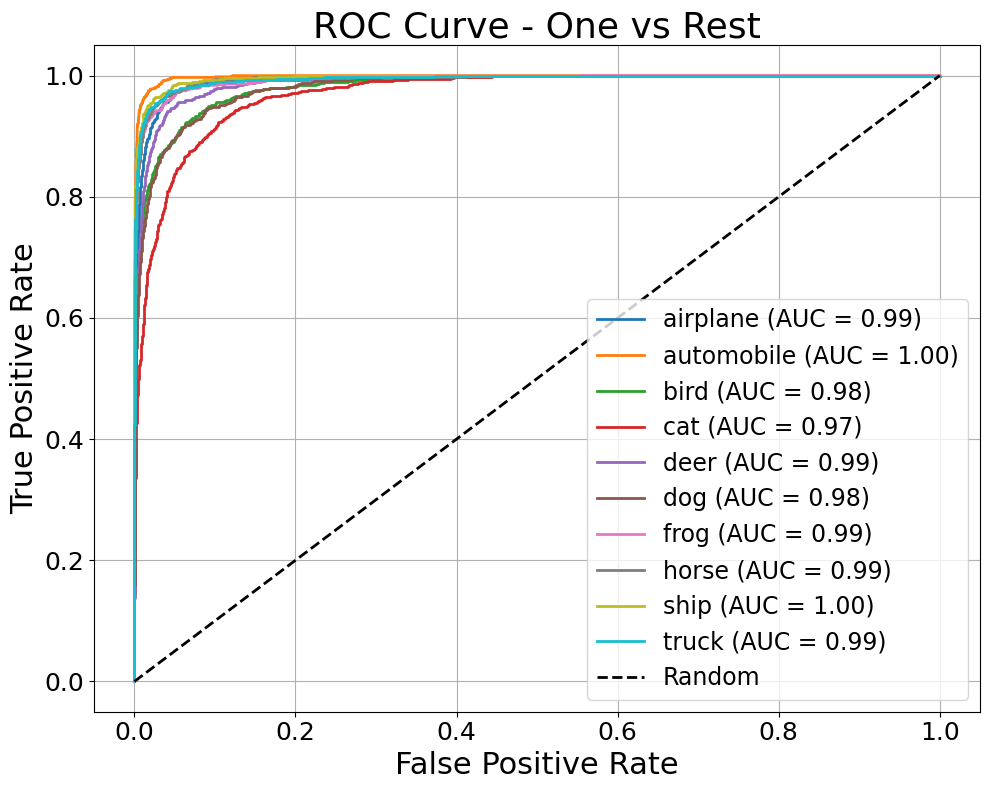

In [ ]:
# Plot ROC curves
# Get true labels and predicted probabilities
test_labels = []
y_score = []

model.eval()
with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        X_batch = X_batch.to(device)

        outputs = model(X_batch)
        probabilities = torch.softmax(outputs, dim=1)

        test_labels.extend(Y_batch.numpy())
        y_score.extend(probabilities.cpu().numpy())

# Binarize labels
n_classes = len(classes)
y_true = label_binarize(test_labels, classes=list(range(n_classes)))
y_score = np.array(y_score)
c
# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2,
        label=f"{classes[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random')

plt.title('ROC Curve - One vs Rest', fontsize=26)
plt.xlabel('False Positive Rate', fontsize=22)
plt.ylabel('True Positive Rate', fontsize=22)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=17)
plt.grid(True)

plt.tight_layout()
plt.savefig(folder_path + "/ROC Curve.pdf", bbox_inches="tight")
plt.show()

## Visualize the confusion matrix


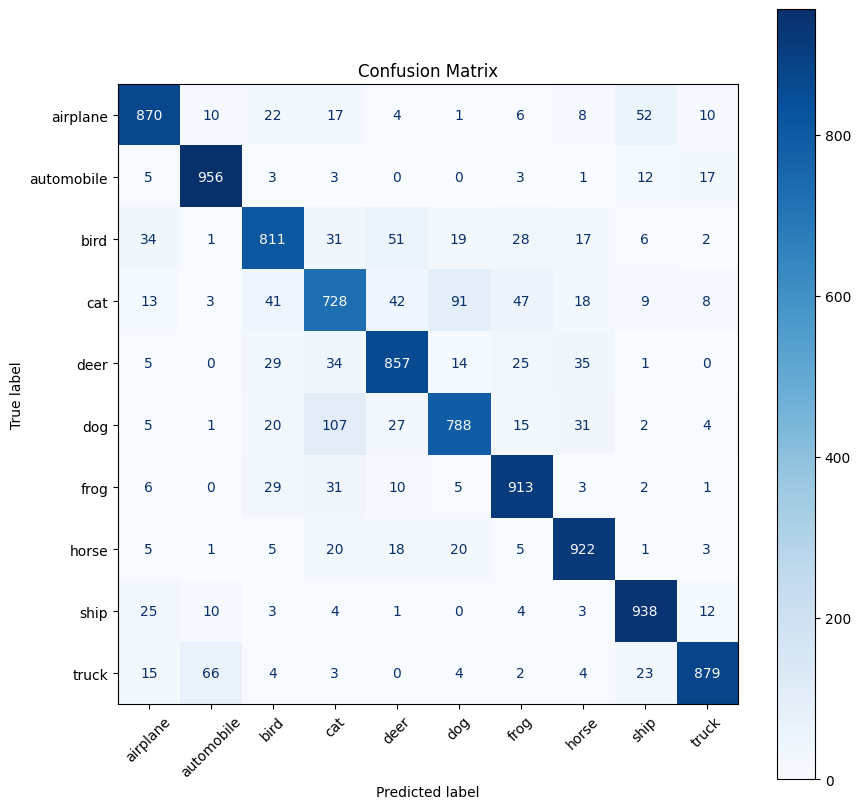

In [10]:
# Confusion matrix
cm = confusion_matrix(y_true_test.numpy(), y_pred_test.numpy())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix")

plt.savefig(folder_path + "/confusion_matrix.pdf")
plt.show()

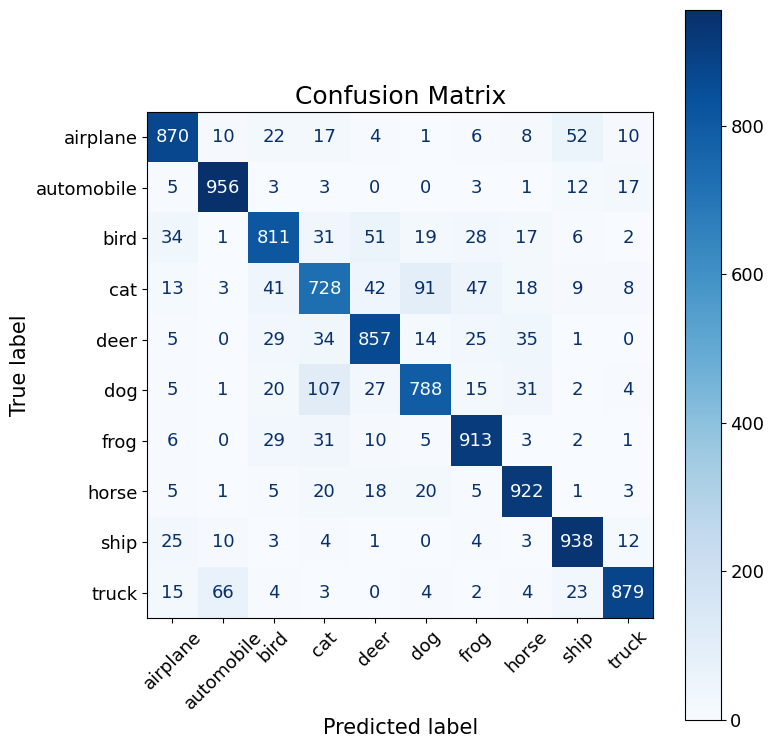

In [ ]:
# Confusion matrix But larger tekst
cm = confusion_matrix(y_true_test.numpy(), y_pred_test.numpy())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)

ax.set_title("Confusion Matrix", fontsize=18)
ax.set_xlabel("Predicted label", fontsize=15)
ax.set_ylabel("True label", fontsize=15)

ax.tick_params(axis="both", labelsize=13)

# Numbers inside the cells
for text in ax.texts:
    text.set_fontsize(13)

# Colorbar font size
cbar = ax.images[-1].colorbar
cbar.ax.tick_params(labelsize=13)

plt.tight_layout()
plt.savefig(folder_path + "/confusion_matrix_thight.pdf", bbox_inches="tight")
plt.show()